In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 단순선형회귀

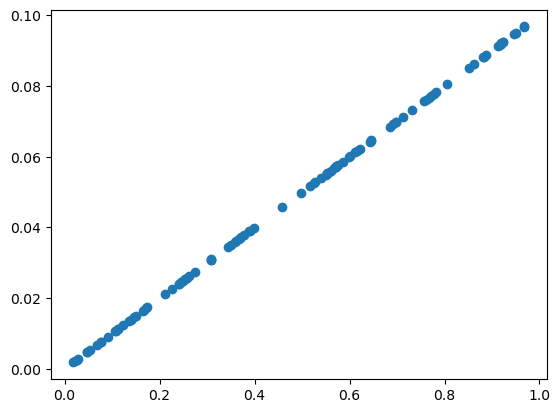

In [2]:
X=np.random.rand(100)
y=0.2*X*0.5
plt.scatter(X,y)

In [3]:
def plt_prediction(pred, y):
    plt.figure(figsize=(8,6))
    plt.scatter(X, y, color='blue', label='Actual')
    plt.scatter(X, pred, color='orange', label='Prediction')
    plt.legend()
    plt.show()

In [4]:
# 경사하강법 y=wX+b , w결정
W = np.random.uniform(-1,1) # X 가중치
b = np.random.uniform(-1,1) # b 편향
learning_rate = 0.5 # 학습률

Epoch 0, W: 0.1247, b: 0.3738, Error: 0.9973


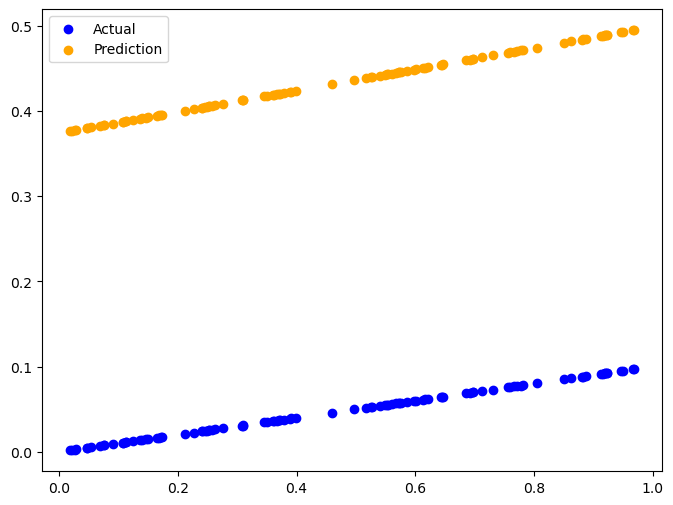

Epoch 10, W: 0.0082, b: 0.0459, Error: 0.0033


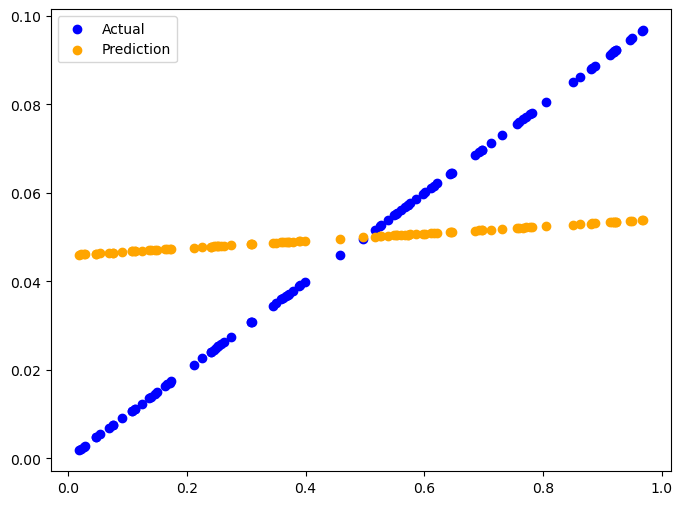

Epoch 20, W: 0.0349, b: 0.0325, Error: 0.0023


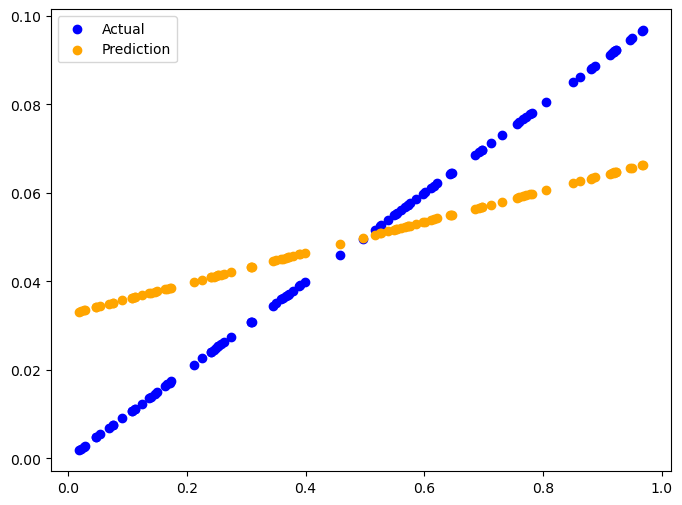

Epoch 30, W: 0.0539, b: 0.0230, Error: 0.0016


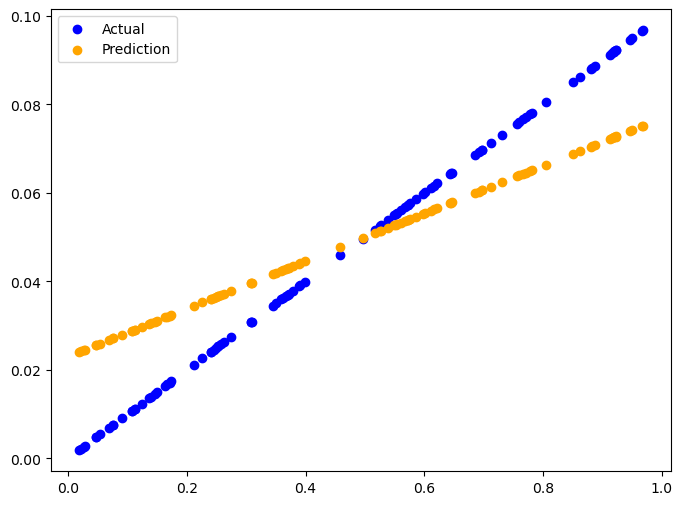

Epoch 40, W: 0.0673, b: 0.0163, Error: 0.0011


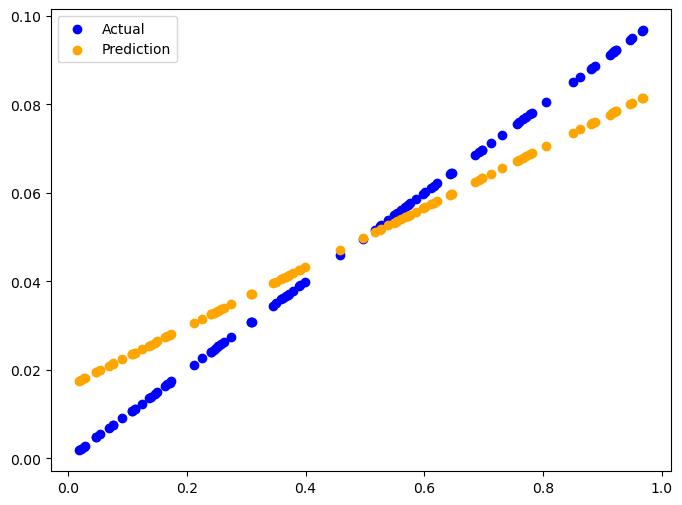

Epoch 50, W: 0.0768, b: 0.0116, Error: 0.0008


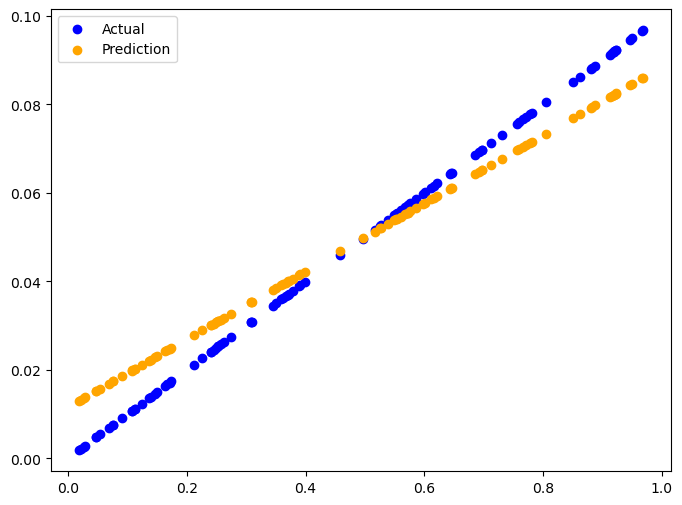

Epoch 60, W: 0.0836, b: 0.0082, Error: 0.0006


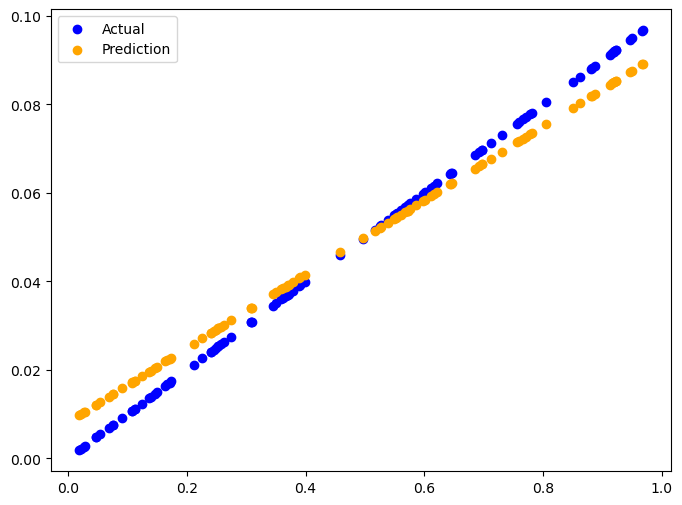

Epoch 70, W: 0.0884, b: 0.0058, Error: 0.0004


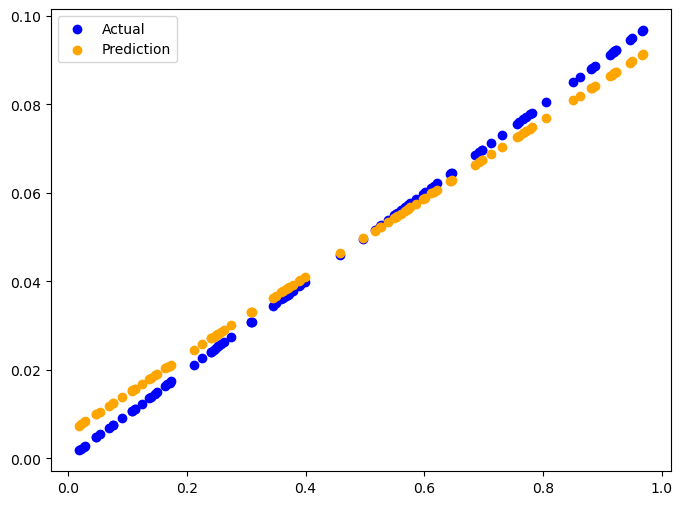

Epoch 80, W: 0.0918, b: 0.0041, Error: 0.0003


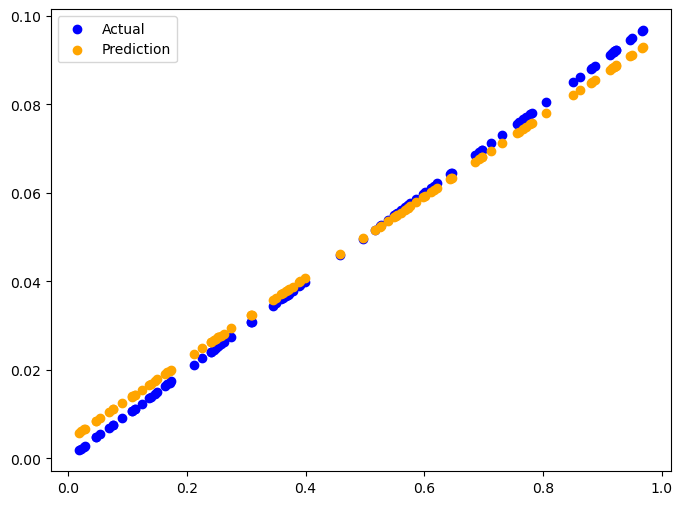

Epoch 90, W: 0.0942, b: 0.0029, Error: 0.0002


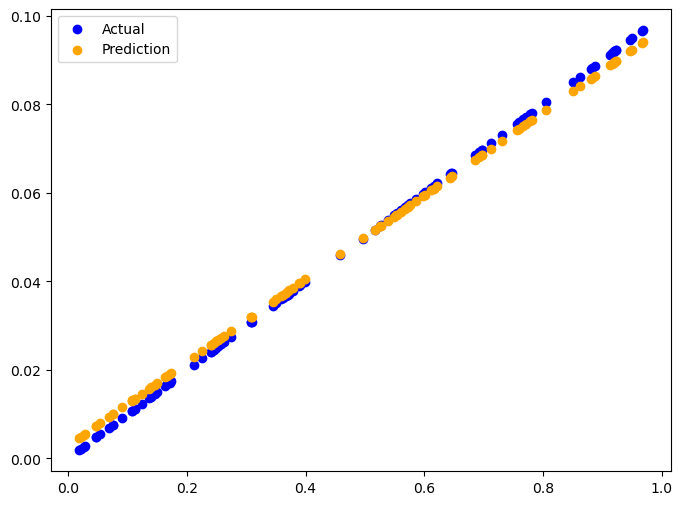

In [5]:
for epoch in range(100):
    pred = W*X + b
    error = (pred - y)
    W_grad = (error * X).mean()
    b_grad = error.mean()
    W -= learning_rate * W_grad
    b -= learning_rate * b_grad
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, W: {W:.4f}, b: {b:.4f}, Error: {error.mean():.4f}')
        y_pred = W*X + b
        plt_prediction(y_pred, y)

# Linear Regression

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
from sklearn.datasets import fetch_california_housing

In [7]:
housing = fetch_california_housing()
house_df = pd.DataFrame(housing.data, columns=housing.feature_names)
house_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [8]:
#target 
house_df['Price'] = housing.target
house_df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'Price'],
      dtype='str')

In [9]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
# 데이터 분할
X = house_df.drop('Price', axis=1).values
y = house_df['Price'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# LinearRegression 모델
house_lr = LinearRegression()
house_lr.fit(X_train, y_train)
house_lr_pred = house_lr.predict(X_test)
house_lr_pred[:10]

array([0.72604907, 1.76743383, 2.71092161, 2.83514727, 2.60695807,
       2.01073856, 2.64067386, 2.16706161, 2.74012056, 3.90361526])

In [12]:
#평가
mse = mean_squared_error(y_test, house_lr_pred)
r2 = r2_score(y_test, house_lr_pred)
mae = np.mean(np.abs(y_test - house_lr_pred))
rmse = np.sqrt(mse)
print(f'MSE: {mse:.4f}, R2: {r2:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}')

MSE: 0.5306, R2: 0.5958, MAE: 0.5272, RMSE: 0.7284


In [13]:
house_lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
house_lr.coef_, house_lr.intercept_

(array([ 4.45822565e-01,  9.68186799e-03, -1.22095112e-01,  7.78599557e-01,
        -7.75740400e-07, -3.37002667e-03, -4.18536747e-01, -4.33687976e-01]),
 np.float64(-37.05624133152509))

In [15]:
pd.Series(data=house_lr.coef_, index=house_df.columns[:-1]).sort_values(ascending=False)

AveBedrms     7.785996e-01
MedInc        4.458226e-01
HouseAge      9.681868e-03
Population   -7.757404e-07
AveOccup     -3.370027e-03
AveRooms     -1.220951e-01
Latitude     -4.185367e-01
Longitude    -4.336880e-01
dtype: float64

- 피처 엔지니어링, 전처리
- 다항회귀, 규제 적용

# 다항회귀모델

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline


In [17]:
model_poly=Pipeline([('poly', PolynomialFeatures(degree=2)),
 ('lr', LinearRegression())])


In [18]:
model_poly.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [19]:
poly_pred = model_poly.predict(X_test)
mse=mean_squared_error(y_test, poly_pred)
r2=r2_score(y_test, poly_pred)
print(f'Polynomial Regression - MSE: {mse:.4f}, R2: {r2:.4f}')


Polynomial Regression - MSE: 0.4550, R2: 0.6534


# 규제 회귀모델 

In [23]:
from sklearn.linear_model import Ridge

# 3. 릿지 회귀
ridge = Ridge(alpha=1.0)  # alpha는 규제 강도
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

print("\n[릿지 회귀]")
print("MSE:", mean_squared_error(y_test, pred_ridge))
print("R2:", r2_score(y_test, pred_ridge))


[릿지 회귀]
MSE: 0.5305052690933699
R2: 0.5958178603951636


In [24]:
from sklearn.linear_model import RidgeCV

# 테스트해보고 싶은 alpha 값 리스트
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print(f"최적의 alpha: {ridge_cv.alpha_}")

최적의 alpha: 0.001


In [ ]:
from sklearn.linear_model import RidgeCV, LassoCV


In [26]:
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)
lasso_preds = lasso_cv.predict(X_test)
lasso_mse = mean_squared_error(y_test, lasso_preds)
lasso_r2 = r2_score(y_test, lasso_preds)
lasso_r2

0.5966991029178372

In [28]:
# 5. 엘라스틱넷 회귀
from sklearn.linear_model import ElasticNet
model_enet = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5: L1과 L2의 비중 50:50
model_enet.fit(X_train, y_train)
pred_enet = model_enet.predict(X_test)

print("\n[엘라스틱넷 회귀]")
print("MSE:", mean_squared_error(y_test, pred_enet))
print("R2:", r2_score(y_test, pred_enet))


[엘라스틱넷 회귀]
MSE: 0.5571449056777037
R2: 0.5755216146456115
